- **Import dependencies**

In [349]:
from sympy.printing.pretty.pretty_symbology import line_width
%reset -f
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import statsmodels.api as sm

- **Load the data**

In [350]:
# Load the data and compute moneyness
data = pd.read_parquet("/Users/Euan Bronsky/Downloads/data_final_final.parquet")
data['K/S'] = data['strike'] / data['underlying_last']

# **Compute summary statistics**

In [351]:
# Compute summary statistics
statistics = data.groupby(['moneyness_group', 'maturity_group'])[['mid', 'iv_fun', 'delta_fun', 'K/S', 'dte', ]].agg(['mean', 'std'])

# Reshape the format and print
table = statistics.stack(0, future_stack=True).unstack(1).swaplevel(0,1, axis=1).reindex(['7-45', '45-90', '90-180', '180-360'],axis=1, level=0).reindex(['DOTM_put', 'OTM_put', 'ATM_put', 'ATM_call', 'OTM_call', 'DOTM_call'], axis=0, level=0)
table

maturity_group                  7-45                 45-90             \
                                mean        std       mean        std   
moneyness_group                                                         
DOTM_put        mid         3.755182   3.976493   6.546927   6.885710   
                iv_fun      0.304537   0.135773   0.340083   0.137998   
                delta_fun  -0.042175   0.034316  -0.041767   0.035150   
                K/S         0.864442   0.086186   0.765334   0.121798   
                dte        23.998623  10.613700  65.199321  12.639702   
OTM_put         mid        22.376229  15.528387  35.955295  23.509036   
                iv_fun      0.190943   0.080321   0.203055   0.066210   
                delta_fun  -0.233410   0.072306  -0.233405   0.072355   
                K/S         0.965706   0.020709   0.940024   0.030197   
                dte        24.282840  10.470682  65.341627  12.660327   
ATM_put         mid        46.956773  27.282540  71.084766  40.240679   
                iv_fun      0.168000   0.075157   0.168619   0.057279   
                delta_fun  -0.436806   0.035986  -0.436545   0.035875   
                K/S         0.994487   0.005008   0.990695   0.007913   
                dte        24.318678  10.404094  65.301054  12.666606   
ATM_call        mid        42.106112  23.580162  60.961390  33.342033   
                iv_fun      0.158291   0.069909   0.156321   0.052199   
                delta_fun   0.439306   0.036327   0.438540   0.036243   
                K/S         1.006869   0.005549   1.011347   0.008712   
                dte        24.211709  10.455594  65.345796  12.612227   
OTM_call        mid        16.695387  12.240049  24.407369  17.399330   
                iv_fun      0.140638   0.061947   0.136139   0.045571   
                delta_fun   0.240449   0.072997   0.239780   0.072930   
                K/S         1.025899   0.015305   1.043094   0.021585   
                dte        24.018473  10.609247  65.427850  12.613208   
DOTM_call       mid         2.337736   2.311229   3.476888   3.545483   
                iv_fun      0.134890   0.061724   0.129315   0.044584   
                delta_fun   0.052416   0.033034   0.050875   0.034358   
                K/S         1.060829   0.038918   1.103674   0.055901   
                dte        24.027225  10.716679  65.170764  12.524175   

maturity_group                 90-180                180-360             
                                 mean        std        mean        std  
moneyness_group                                                          
DOTM_put        mid         11.371709  11.877768   17.719455  17.908458  
                iv_fun       0.370875   0.140623    0.368757   0.124831  
                delta_fun   -0.041393   0.035605   -0.042817   0.035659  
                K/S          0.671543   0.151120    0.587986   0.160024  
                dte        131.093732  26.427495  267.749985  52.235252  
OTM_put         mid         65.334733  38.254650   97.445519  55.846619  
                iv_fun       0.225722   0.062248    0.235576   0.053294  
                delta_fun   -0.233257   0.072182   -0.231861   0.072036  
                K/S          0.911992   0.042941    0.877366   0.057011  
                dte        131.894849  26.772929  272.434755  52.470510  
ATM_put         mid        128.526691  62.651539  188.548088  89.710930  
                iv_fun       0.187014   0.052190    0.194877   0.042594  
                delta_fun   -0.434020   0.035133   -0.430884   0.034469  
                K/S          0.988771   0.012510    0.986144   0.018865  
                dte        131.449884  26.916332  271.539839  52.648716  
ATM_call        mid        105.836868  48.642064  146.314668  64.929691  
                iv_fun       0.172991   0.048270    0.179070   0.039706  
                delta_fun    0.437570   0.035654    0.434746   0.034231  
                K/S          1.02152

# **Initial plots of the surface**

- **Prepare data**

In [352]:
# Extract two specific dates
date_2020 = data[(data["quote_date"] == "2020-03-04") & (data["delta_fun"] > -0.5) & (data['option_type'] == 'put')]
date_2016 = data[(data["quote_date"] == "2016-03-21") & (data["delta_fun"] > -0.5) & (data['option_type'] == 'put')]

# Extract relevant 2016 variables
deltas_2020 = date_2020['delta_fun']
ivs_2020 = date_2020['iv']
dtes_2020 = date_2020['dte']

# Extract relevant 2020 variables
deltas_2016 = date_2016['delta_fun']
ivs_2016 = date_2016['iv']
dtes_2016 = date_2016['dte']

- **Plot the surfaces**

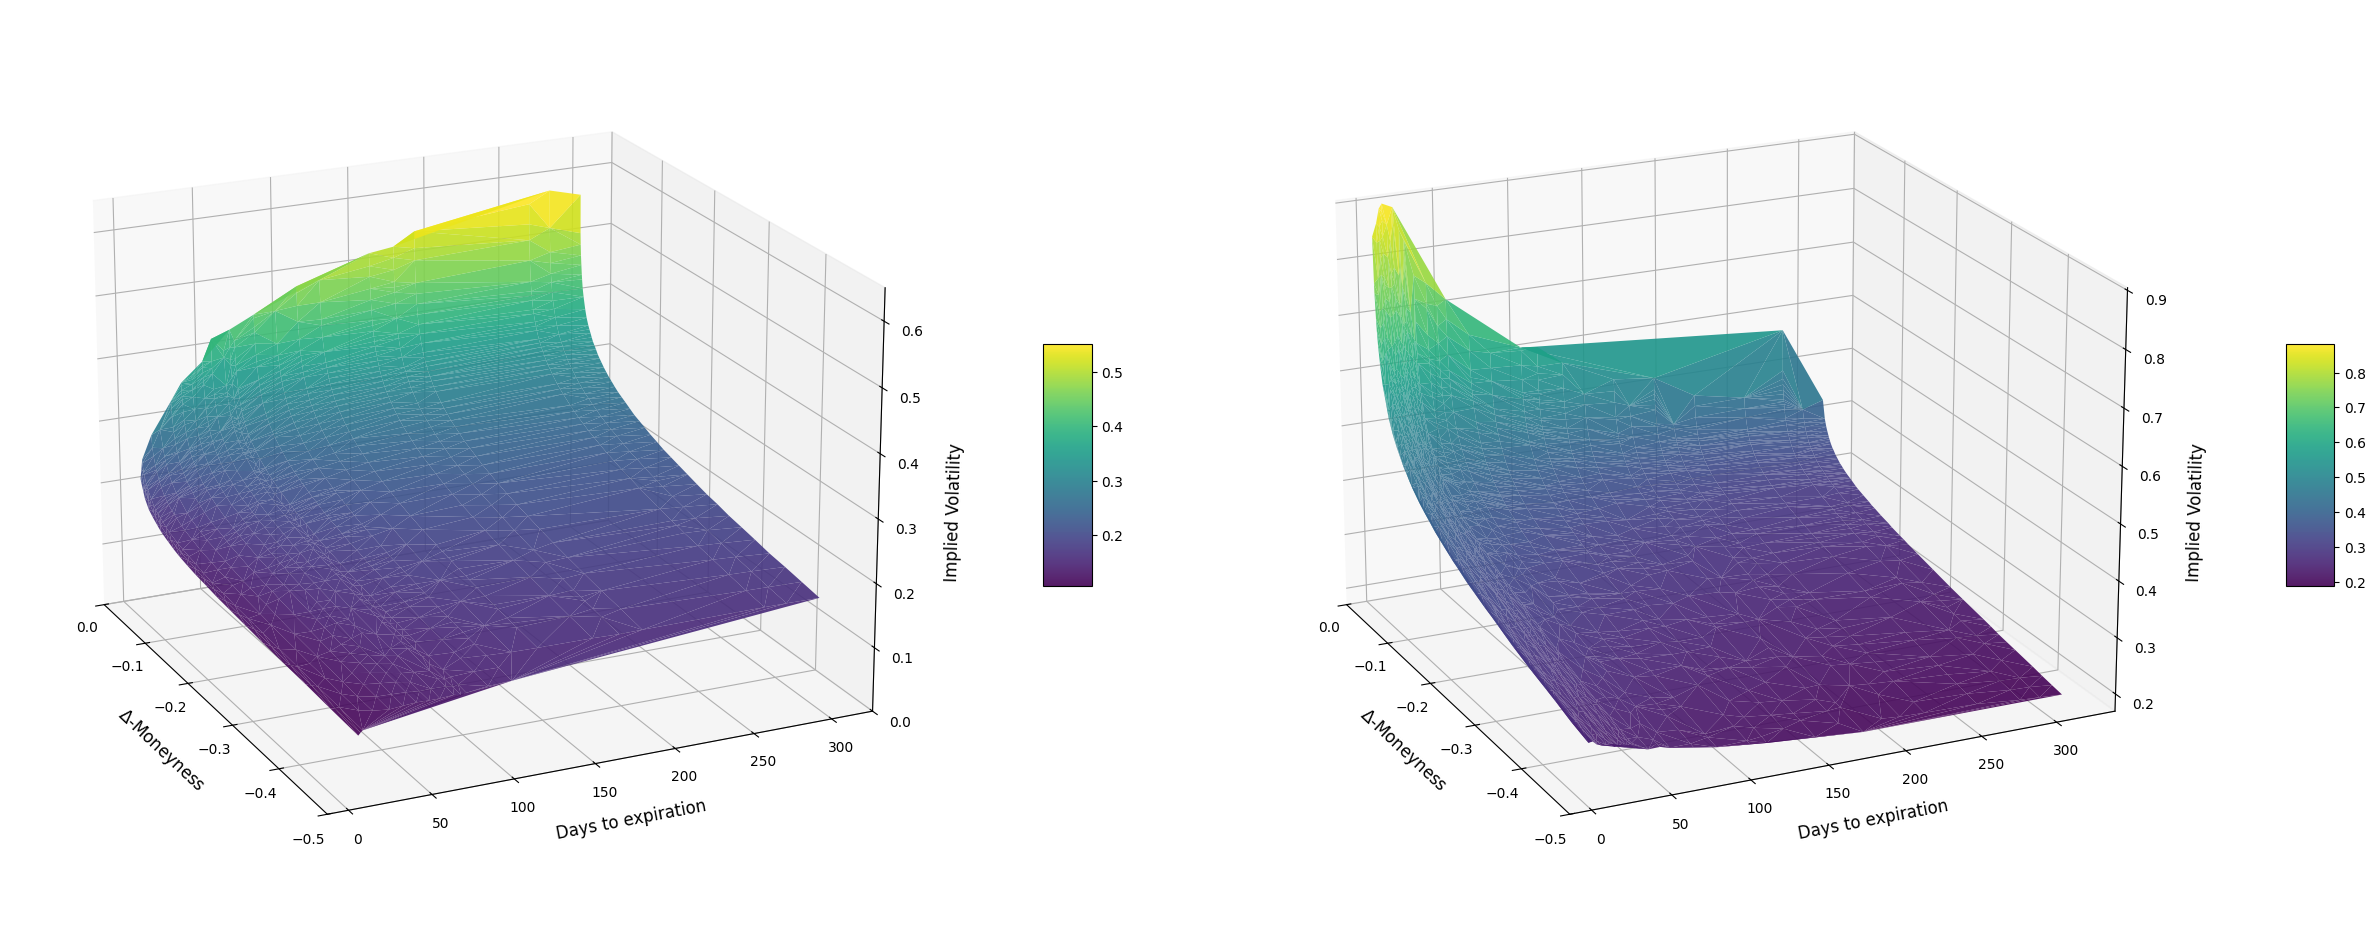

In [353]:
#%matplotlib notebook
#%matplotlib inline

# Set up figure environment
fig, axes = plt.subplots(1,2,figsize=(25,10), subplot_kw={'projection':'3d'})
fig.subplots_adjust(wspace=3)

# 2016 plot
surf1 = axes[0].plot_trisurf(deltas_2016, dtes_2016, ivs_2016,
                       cmap='viridis',
                       linewidth=0.1,
                       antialiased=True,
                       alpha=0.9)

# 2020 plot
surf2 = axes[1].plot_trisurf(deltas_2020, dtes_2020, ivs_2020,
                       cmap='viridis',
                       linewidth=0.1,
                       antialiased=True,
                       alpha=0.9)

# Set x-axis limits
axes[0].set_zlim(0, 0.65)

# Set common specifications
for ax in axes.flat:
    ax.set_xlabel(r'$\Delta$-Moneyness', labelpad=10, fontsize=12)
    ax.set_ylabel('Days to expiration', labelpad=10, fontsize=12)
    ax.set_zlabel('Implied Volatility', labelpad=10, fontsize=12)
    ax.set_xlim(0, -0.5)
    #ax.invert_xaxis()
    ax.view_init(elev=20, azim=-25)

# Plot the colorbars
fig.colorbar(surf1, ax=axes[0], shrink=0.25, aspect=5, pad=0.1)
fig.colorbar(surf2, ax=axes[1], shrink=0.25, aspect=5, pad=0.1)

# Plot the results
plt.tight_layout()
#plt.savefig("/Users/euanbronsky/Downloads/Initial.IV.Plot.png", bbox_inches='tight')
plt.show()

# **Correlations**

- **Obtain data with only one selected contract per bucket**

In [354]:
# Compute standard deviations
sigma_delta = data['delta_fun'].std()
sigma_t = data['dte'].std()

# Compute distance
data['distance'] = ((data['delta_fun'] - data['delta_star'])**2 / sigma_delta**2 + (data['dte'] - data['t_star'])**2 / sigma_t**2)

# Locate the index of the groups that minimizes that respective groups distance
df_selected = data.loc[data.groupby(['quote_date','moneyness_group', 'maturity_group'])['distance'].idxmin()].reset_index(drop=True)

# Compute the log implied volatility
df_selected['log_iv'] = np.log(df_selected['iv_fun'])

- **Reshape the data and demean**

In [355]:
def run_pca(df, value_col):

    # Pivot
    pivot = df.pivot_table(
        index = 'quote_date',
        columns = ['moneyness_group', 'maturity_group'],
        values = value_col)

    # Drop NaNs and demean for PCA
    pivot = pivot.dropna()
    X = pivot - pivot.mean()

    # Conduct PCA
    pca = PCA()
    PCs = pca.fit_transform(X)

    # Return the results
    return {
        'pivot': pivot,
        'PCs': PCs,
        'explained_variance': pca.explained_variance_ratio_,
        'cum_variance': np.cumsum(pca.explained_variance_ratio_),
        'X': X}

In [356]:
# Obtain the reshaped table
df_pivot = run_pca(df_selected, 'log_iv')['pivot']

- **Compute correlations**

In [357]:
# Specify lags
lags = [1, 2, 3, 4, 5, 10]

# Specify columns to use
cols = df_pivot.columns[df_pivot.columns.get_level_values(1).isin(['7-45', '180-360'])]

# Compute ACF and PACF
acf_vals = [sm.tsa.stattools.acf(df_pivot[col])[lags] for col in cols]
pacf_vals = [sm.tsa.stattools.pacf(df_pivot[col])[lags] for col in cols]

# Store results in DataFrame
df_acf = pd.DataFrame(acf_vals, index=cols, columns=[f'ACF{l}' for l in lags])
df_pacf = pd.DataFrame(pacf_vals, index=cols, columns=[f'PACF{l}' for l in lags])

# Concatenate the resutls
df_acf_pacf = pd.concat([df_acf, df_pacf], axis=1)
print(df_acf_pacf)

                                    ACF1      ACF2      ACF3      ACF4  \
moneyness_group maturity_group                                           
ATM_call        180-360         0.986835  0.978548  0.969241  0.960220   
                7-45            0.963617  0.940943  0.920468  0.899877   
ATM_put         180-360         0.986922  0.977729  0.968697  0.959446   
                7-45            0.965502  0.941165  0.919811  0.899199   
DOTM_call       180-360         0.989136  0.982630  0.975119  0.968016   
                7-45            0.973092  0.955399  0.939362  0.924320   
DOTM_put        180-360         0.988279  0.979808  0.971694  0.963231   
                7-45            0.956220  0.923666  0.896149  0.870382   
OTM_call        180-360         0.988164  0.980567  0.972221  0.964048   
                7-45            0.968855  0.950007  0.930506  0.913295   
OTM_put         180-360         0.987344  0.978208  0.968910  0.959714   
                7-45            0.9643

- **Compute cross-correlations**

In [358]:
# Short maturity group
short_mat_group = df_pivot.loc[:, df_pivot.columns.get_level_values(1) == '7-45']

# Long maturity group
long_mat_group = df_pivot.loc[:, df_pivot.columns.get_level_values(1) == '180-360']

# Cross correlations
combined = pd.concat([short_mat_group, long_mat_group], axis=1)
corr_combined = combined.corr()
print(corr_combined)

moneyness_group                 ATM_call   ATM_put DOTM_call  DOTM_put  \
maturity_group                      7-45      7-45      7-45      7-45   
moneyness_group maturity_group                                           
ATM_call        7-45            1.000000  0.989622  0.973833  0.942154   
ATM_put         7-45            0.989622  1.000000  0.961695  0.952597   
DOTM_call       7-45            0.973833  0.961695  1.000000  0.901697   
DOTM_put        7-45            0.942154  0.952597  0.901697  1.000000   
OTM_call        7-45            0.993633  0.984769  0.987800  0.926229   
OTM_put         7-45            0.983202  0.992489  0.946092  0.974639   
ATM_call        180-360         0.926546  0.922394  0.926775  0.890647   
ATM_put         180-360         0.920971  0.921966  0.917590  0.892859   
DOTM_call       180-360         0.895016  0.887102  0.924738  0.853247   
DOTM_put        180-360         0.866702  0.868253  0.861978  0.883090   
OTM_call        180-360         0.9185

# **Principal component analysis**

- **Apply principal component analysis**

In [359]:
# Apply the PCA function
res_log = run_pca(df_selected, 'log_iv')
res_iv  = run_pca(df_selected, 'iv_fun')

# Extract the principal components
PC1, PC2, PC3 = res_log['PCs'][:, 0], res_log['PCs'][:, 1], res_log['PCs'][:, 2]
PC1_2, PC2_2, PC3_2 = res_iv['PCs'][:, 0], res_iv['PCs'][:, 1], res_iv['PCs'][:, 2]

# DataFrame for log_iv
pc_explained_log = pd.DataFrame({
    '%': res_log['explained_variance'],
    'Cum. %': res_log['cum_variance']
}, index=[f'PC{i}' for i in range(1, len(res_log['cum_variance']) + 1)])

# DataFrame for regular IV
pc_explained_iv = pd.DataFrame({
    '%': res_iv['explained_variance'],
    'Cum. %': res_iv['cum_variance']
}, index=[f'PC{i}' for i in range(1, len(res_iv['cum_variance']) + 1)])

# Combined table
combined_table = pd.concat([pc_explained_log, pc_explained_iv], axis=1)
combined_table

,%,Cum. %,%,Cum. %
PC1,0.954848,0.954848,0.948599,0.948599
PC2,0.018881,0.973729,0.026073,0.974672
PC3,0.014538,0.988267,0.015409,0.990080
PC4,0.003967,0.992234,0.002741,0.992821
PC5,0.002127,0.994361,0.002300,0.995121
PC6,0.001686,0.996047,0.001671,0.996792
PC7,0.000846,0.996893,0.000632,0.997425
PC8,0.000588,0.997482,0.000493,0.997918
PC9,0.000497,0.997979,0.000352,0.998270
PC10,0.000346,0.998325,0.000319,0.998589


- **Compute ACF and PACF**

In [360]:
# Store list of principal components
pcs_list = [PC1, PC2, PC3]

# Compute the ACF
acf_pc = [sm.tsa.stattools.acf(pc, nlags=max(lags))[lags] for pc in pcs_list]

# Compute the PACF
pacf_pc = [sm.tsa.stattools.pacf(pc, nlags=max(lags))[lags] for pc in pcs_list]


- **Present
the
ACF and PACF**

In [361]:
# Create list of index names
index_list = ['PC1', 'PC2', 'PC3']

# Store ACF results
df_acf_pc = pd.DataFrame(acf_pc, index = index_list, columns=[f'ACF{l}' for l in lags])

# Store PACF results
df_pacf_pc = pd.DataFrame(pacf_pc, index = index_list, columns=[f'PACF{l}' for l in lags])

# COncatenate and print the results
df_acf_pacf_pc = pd.concat([df_acf_pc, df_pacf_pc], axis=1)
df_acf_pacf_pc

,ACF1,ACF2,ACF3,ACF4,ACF5,ACF10,PACF1,PACF2,PACF3,PACF4,PACF5,PACF10
PC1,0.979971,0.964507,0.949986,0.935915,0.923217,0.870639,0.980255,0.106548,0.029823,0.011306,0.032728,-0.013395
PC2,0.930291,0.883038,0.840967,0.804597,0.772231,0.659343,0.930561,0.131331,0.039999,0.037062,0.029368,0.038275
PC3,0.939682,0.904023,0.869518,0.837302,0.812263,0.736448,0.939955,0.180553,0.034097,0.015062,0.057905,0.031558


- **Define the mean, maturity spread, and moneyness spread**

In [362]:
# Mean series
mean_series = df_pivot.mean(axis=1)

# Maturity spread series, extract maturities 7-45 and 180-360
short_iv = df_pivot.loc[:, df_pivot.columns.get_level_values(1) == '7-45'].mean(axis=1)
long_iv = df_pivot.loc[:, df_pivot.columns.get_level_values(1) == '180-360'].mean(axis=1)

# Compute the maturity spread
ttm_spread = short_iv - long_iv

# Moneyness spread series, extract two opposing DOTM options
low = df_pivot.loc[:,df_pivot.columns.get_level_values(0) == 'DOTM_put'].mean(axis=1)
high = df_pivot.loc[:,df_pivot.columns.get_level_values(0) == 'DOTM_call'].mean(axis=1)

# Compute the moneyness spread
mm_spread = high - low

# Account for negative correlations
if np.corrcoef(PC2, ttm_spread)[0, 1] < 0:
    PC2 = -PC2
if np.corrcoef(PC3, mm_spread)[0, 1] < 0:
    PC3 = -PC3

- **Plot the results**

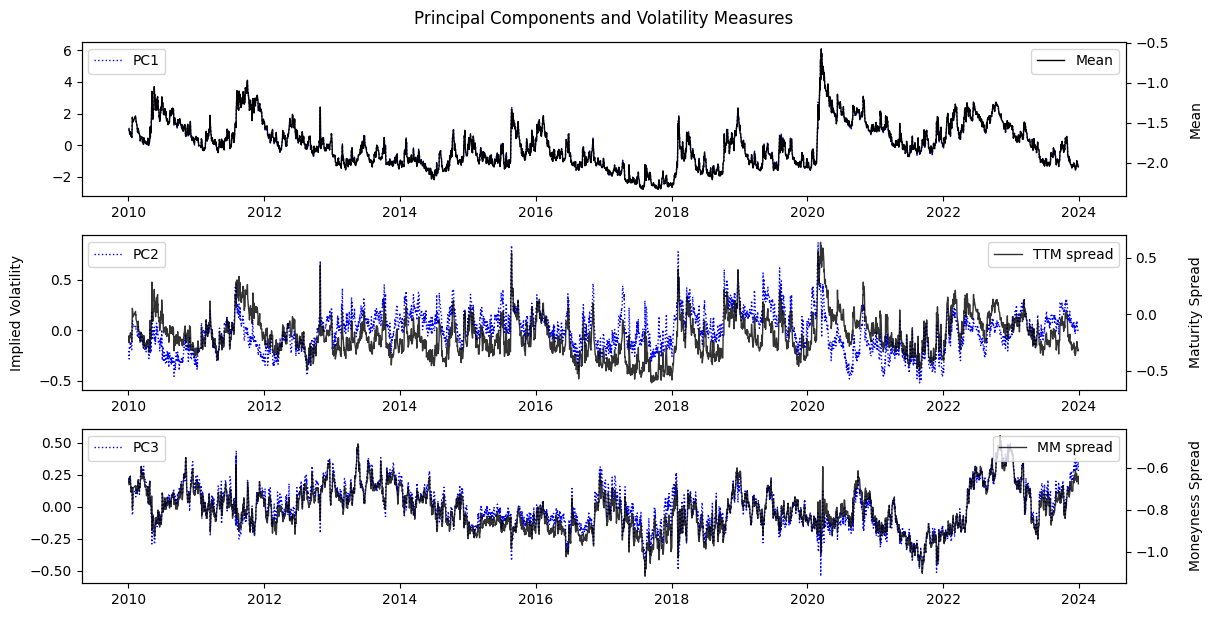

In [363]:
# Create helper function for the legend
#def add_legend(ax_left, ax_right, loc='lower left'):
 #   lines1, labels1 = ax_left.get_legend_handles_labels()
  #  lines2, labels2 = ax_right.get_legend_handles_labels()
   # ax_left.legend(lines1 + lines2, labels1 + labels2, loc=loc)

# Define plotting environment
fig, axes = plt.subplots(3, 1, figsize=(12, 6))

# Plot the mean series
ax1 = axes[0]
ax2 = ax1.twinx()
ax1.plot(df_pivot.index, PC1, label = 'PC1', color = 'blue', linestyle = ':', linewidth = 1)
ax2.plot(df_pivot.index, mean_series, color = 'black', label = 'Mean', alpha=1, linewidth = 1)
#add_legend(ax1, ax2, loc='upper left')
#ax1.set_ylabel('Implied Volatility', fontsize=10)
#ax1.set_title('Factor 1 vs. Average Implied Volatility', fontsize=11)
ax2.set_ylabel('Mean', fontsize=10)

# PC legend (top)
ax1.legend(loc='upper left')

# Mean legend (bottom)
ax2.legend(loc='upper right')

# Plot the time-to-maturity spread
ax3 = axes[1]
ax4 = ax3.twinx()
ax3.plot(df_pivot.index, PC2, label = 'PC2', color='blue', linestyle = ':', linewidth = 1)
ax4.plot(df_pivot.index, ttm_spread, color='black', label = 'TTM spread', alpha=0.8, linewidth=1)
#add_legend(ax3, ax4, loc='upper left')
#ax3.set_title('Factor 2 vs. Slope of Volatility Term Structure', fontsize=11)
ax3.set_ylabel('Implied Volatility', fontsize=10)
ax4.set_ylabel('Maturity Spread', fontsize=10)

# Second subplot
ax3.legend(loc='upper left')   # PC2
ax4.legend(loc='upper right')   # TTM spread

# Plot the moneyness spread
ax5 = axes[2]
ax6 = ax5.twinx()
ax5.plot(df_pivot.index, PC3, label = 'PC3', color='blue', linestyle = ':', linewidth = 1)
ax6.plot(df_pivot.index, mm_spread, color = 'black', label = 'MM spread', alpha=0.8, linewidth = 1)
#add_legend(ax5, ax6, loc='upper left')
#ax5.set_title('Factor 3 vs. Slope of Volatility Smile', fontsize=11)
#ax5.set_ylabel('Implied Volatility', fontsize=10)
ax6.set_ylabel('Moneyness Spread', fontsize=10)

# Third subplot
ax5.legend(loc='upper left')   # PC3
ax6.legend(loc='upper right')

#for ax in axes.flat:
    #ax.grid(True, alpha=0.5)

# Plot the results
plt.tight_layout()
fig.suptitle('Principal Components and Volatility Measures', fontsize=12, y=1.02)
fig.align_ylabels(axes)
for ax in [ax2, ax4, ax6]:
    ax.yaxis.set_label_coords(1.06, 0.5)
plt.savefig("/Users/Euan Bronsky/Downloads/pca.plot.png", bbox_inches='tight')
plt.show()